# TP5 AA1 Clasificación

ALUMNO: Moises Lobayza

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

**LEA LAS INDICACIONES DE ENTREGA EN EL FORO DE LA TAREA**

#**Tarea: Entrenamiento y evaluación de clasificadores**  

**Objetivo**: Aplicar un modelo de clasificación a un dataset de su elección, procesar dicho dataset para poder usarlo para entrenamiento, indicar y compartir todos los recursos utilizados, evaluar su rendimiento.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets?Task=Classification&skip=0&take=10&sort=desc&orderBy=Relevance&search=
   - Requisitos:  
     - Debe tener al menos 4 variables.
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

# Librerias

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Elección del dataset

Elegí el dataset Raisin del UCI Machine Learning Repository porque corresponde a un problema de clasificación binaria entre dos variedades de pasas de uva: Kecimen y Besni. El dataset tiene 900 instancias, 7 variables predictoras morfológicas y no presenta valores faltantes. Además, las clases están balanceadas, ya que hay 450 ejemplos de cada tipo. Por eso resulta adecuado para aplicar modelos de clasificación como Logistic Regression, KNN o SVM, evaluar su rendimiento y comparar métricas.

link: https://archive.ics.uci.edu/dataset/850/raisin

# Carga de datos

In [57]:
file_id = "1kP4JrDXVWovtIgOYzEtHUm3Mxwt-XwwT"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_excel(url)
display(df.head())

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen



## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - Describan si observan o no relaciones entre algunas variables.  


## Resolución:

# Información general del dataset

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


In [59]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [60]:
df.isnull().sum()

,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
Extent,0
Perimeter,0
Class,0


In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df["Class"].value_counts()

,count
Class,
Kecimen,450
Besni,450


El dataset tiene **900 registros y 8 columnas** : **7 variables predictoras numéricas y una variable objetivo llamada Class**. No se observan valores nulos, por lo que no es necesario realizar imputación de datos. Además, la variable objetivo está perfectamente balanceada, ya que hay 450 registros de Kecimen y 450 de Besni.

En las estadísticas descriptivas se observa que las variables relacionadas al tamaño, como Area, ConvexArea y Perimeter, tienen bastante variabilidad, lo que puede ser útil para diferenciar entre las dos clases de pasas.

**Separar variables numéricas y target**

In [63]:
target = "Class"

features = df.drop(columns=[target]).columns
features

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'Extent', 'Perimeter'],
      dtype='object')

**Histogramas para ver distribución**

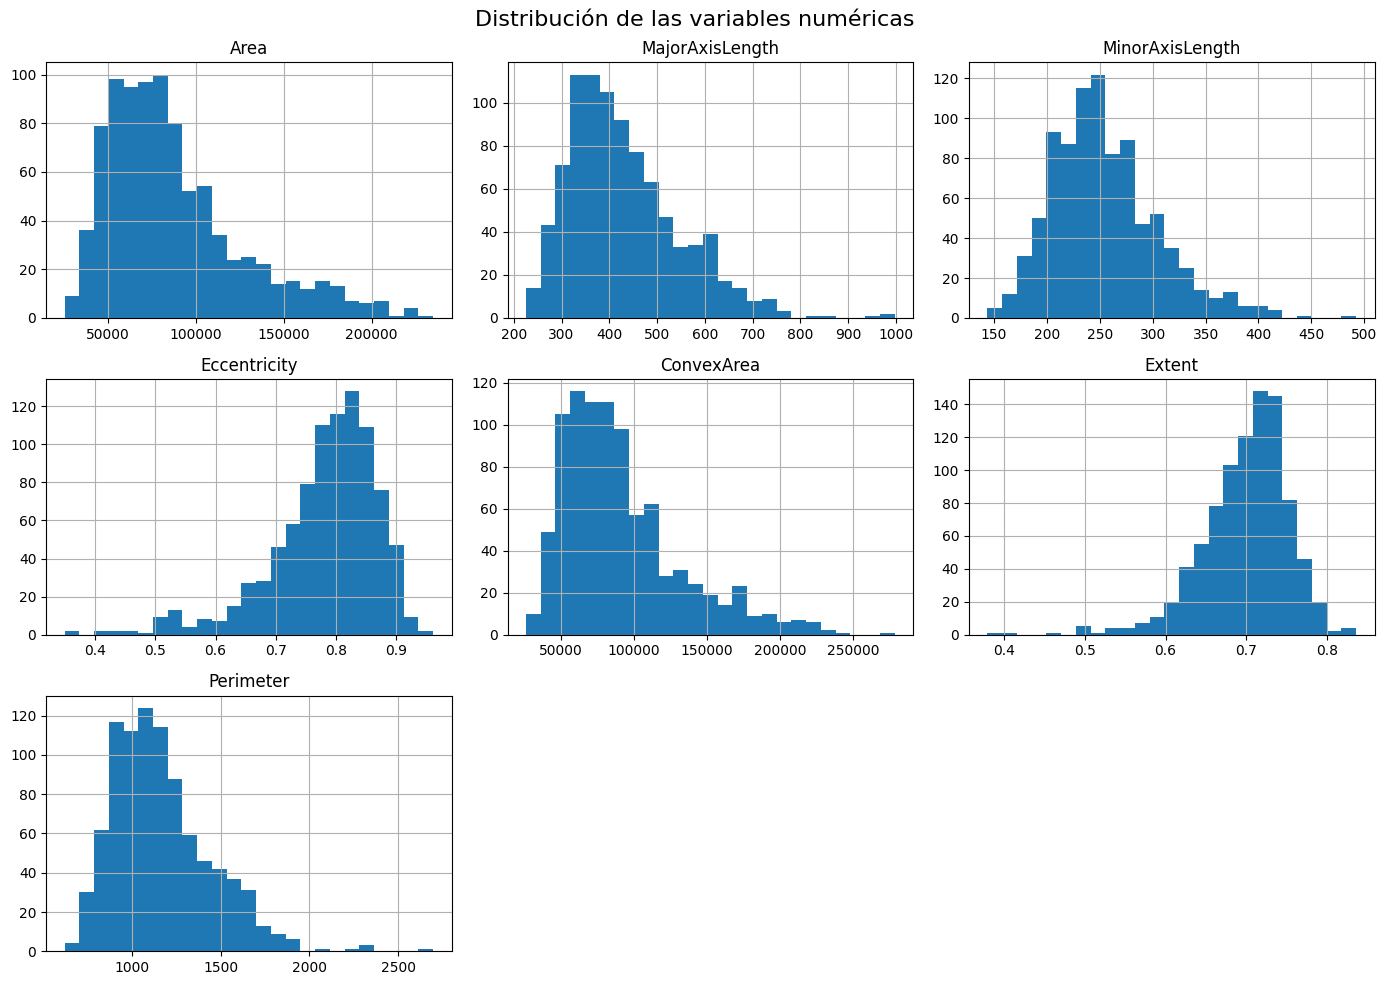

In [64]:
df[features].hist(figsize=(14, 10), bins=25)
plt.suptitle("Distribución de las variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

En los histogramas se observa que varias variables, como Area, ConvexArea, MajorAxisLength y Perimeter, presentan una distribución asimétrica hacia la derecha. Esto significa que la mayoría de las pasas tienen valores medios o bajos, pero existen algunos casos con valores mucho más altos. Las variables Eccentricity y Extent se concentran más en rangos específicos, mostrando menor dispersión.

**Boxplots por clase**

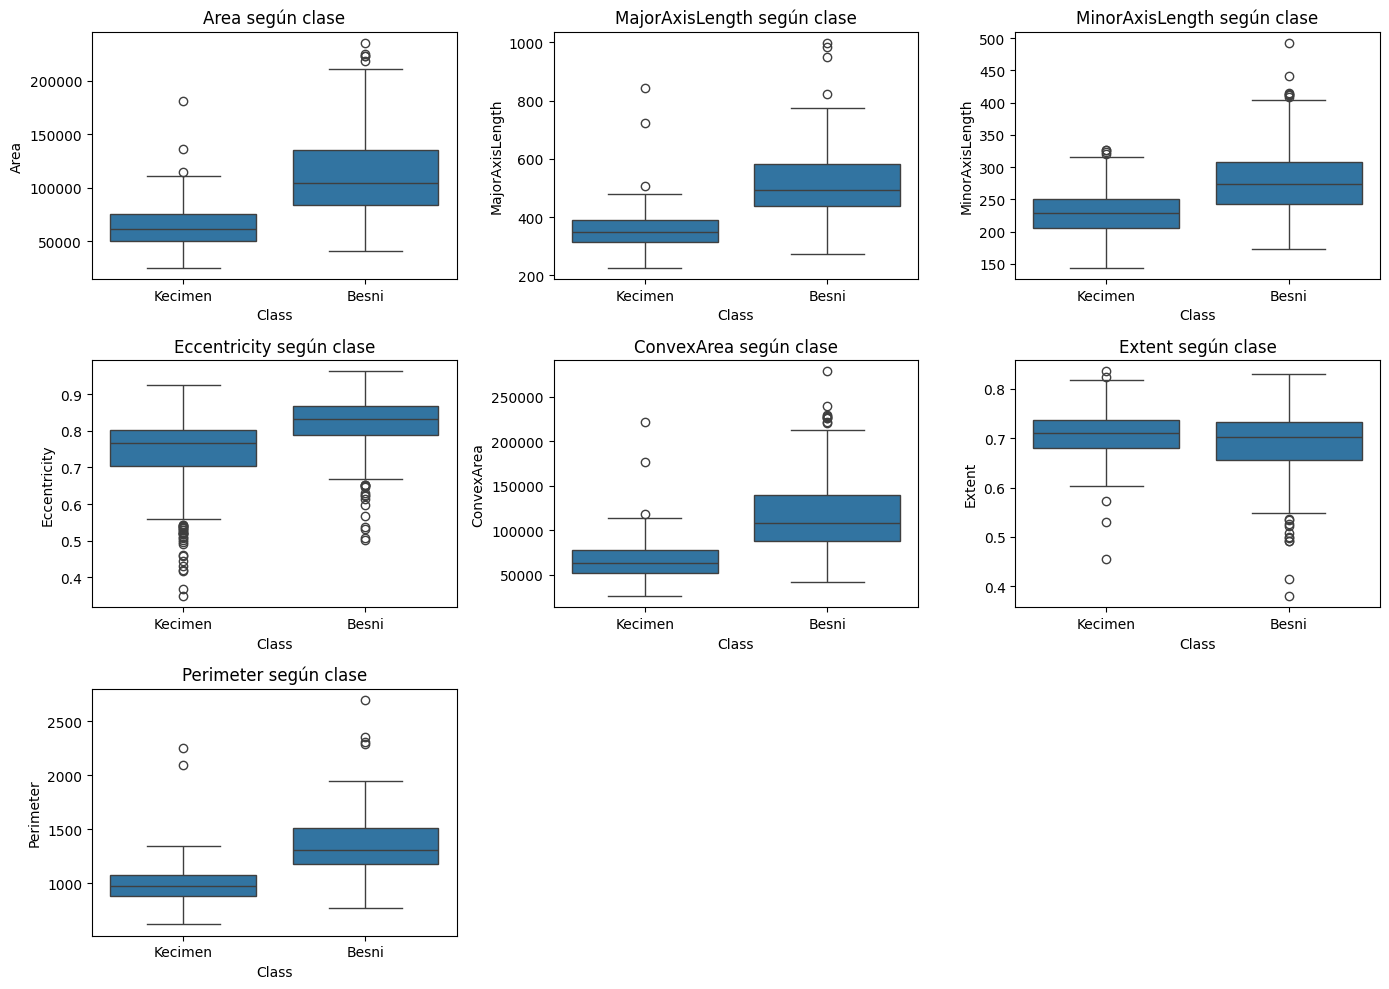

In [65]:
plt.figure(figsize=(14, 10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f"{col} según clase")

plt.tight_layout()
plt.show()

En los boxplots se observa que la clase Besni suele presentar valores más altos que Kecimen en variables como Area, MajorAxisLength, MinorAxisLength, ConvexArea y Perimeter. Esto indica que las pasas Besni tienden a ser más grandes o tener mayor perímetro. También se observan algunos valores atípicos en ambas clases.

**Scatterplots entre variables, coloreando por clase**

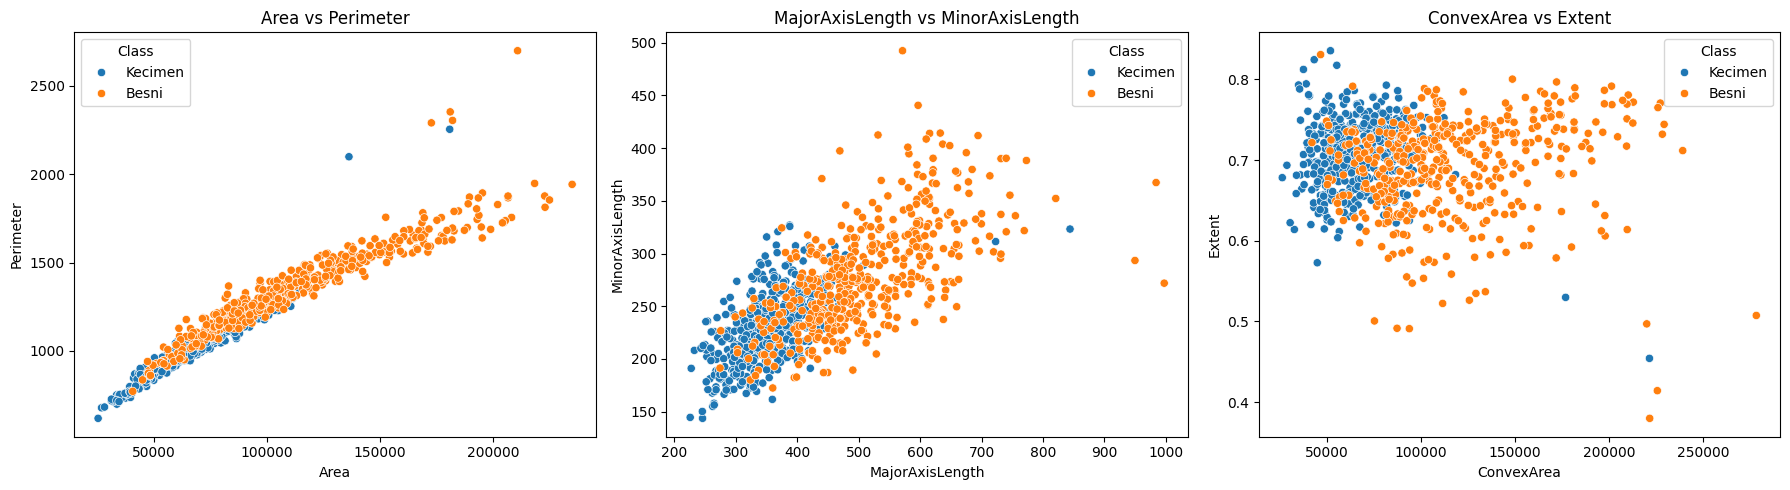

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1
sns.scatterplot(data=df, x="Area", y="Perimeter", hue="Class", ax=axes[0])
axes[0].set_title("Area vs Perimeter")

# Gráfico 2
sns.scatterplot(data=df, x="MajorAxisLength", y="MinorAxisLength", hue="Class", ax=axes[1])
axes[1].set_title("MajorAxisLength vs MinorAxisLength")

# Gráfico 3
sns.scatterplot(data=df, x="ConvexArea", y="Extent", hue="Class", ax=axes[2])
axes[2].set_title("ConvexArea vs Extent")

plt.tight_layout()
plt.show()

En los scatterplots se observa una relación positiva entre algunas variables: a mayor Area, mayor Perimeter, y a mayor MajorAxisLength, mayor MinorAxisLength. También se ve que la clase Besni tiende a ubicarse en valores más altos, mientras que Kecimen aparece más concentrada en valores menores. Sin embargo, existe cierta superposición entre clases, por lo que será necesario usar un modelo que combine varias variables para clasificar mejor.

**Matriz de correlación**

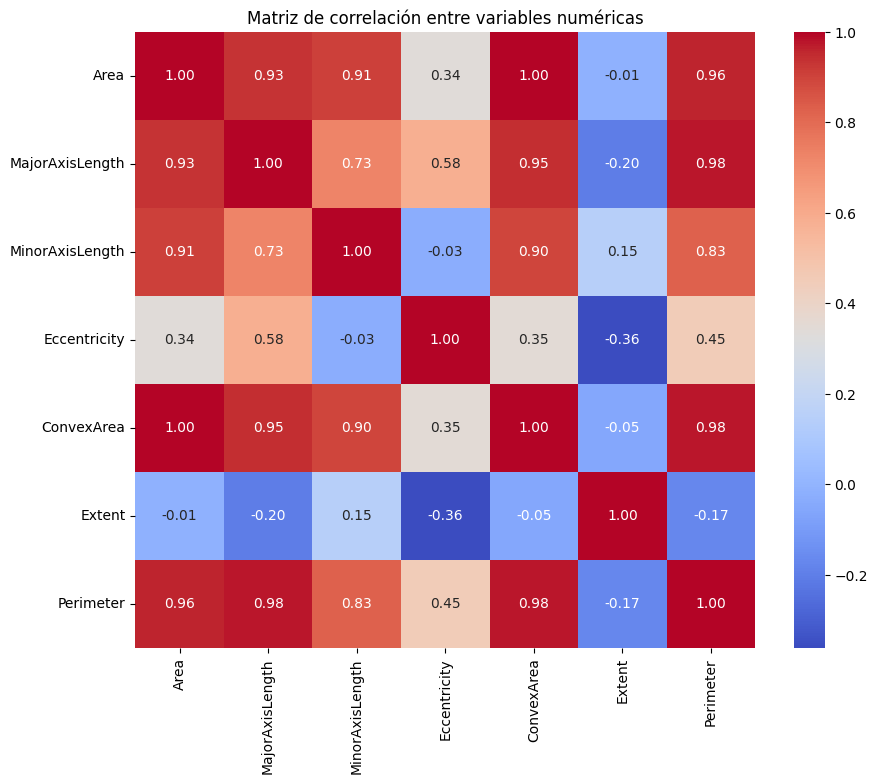

In [68]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

En la matriz de correlación se observa una relación muy fuerte entre variables asociadas al tamaño de la pasa, como Area, ConvexArea y Perimeter. También MajorAxisLength se relaciona fuertemente con Perimeter y ConvexArea. Esto indica que varias variables aportan información similar sobre el tamaño general de la pasa.

Por otro lado, Extent presenta correlaciones bajas o negativas con la mayoría de las variables, por lo que podría aportar información distinta al modelo. En general, estas relaciones muestran que hay variables conectadas entre sí, algo esperable porque todas describen características geométricas de la pasa.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Otros pasos que crea conveniente para pre-procesar el dataset (mencione y explique)

Detalla las caracteristicas del dataset como nro de variables, nro de filas o instancias, si el problema es clasificacion binaria o multiclase, y otras características que crea conveniente.

Realice la división de datos (entrenamiento / testeo / CV según corresponda)

## Resolución:

**Veamos los outliers**

In [69]:
features = df.drop(columns=["Class"]).columns

Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[features] < (Q1 - 1.5 * IQR)) |
            (df[features] > (Q3 + 1.5 * IQR))).sum()

outliers

,0
Area,41
MajorAxisLength,17
MinorAxisLength,26
Eccentricity,43
ConvexArea,42
Extent,21
Perimeter,17


Durante el EDA no se detectaron valores faltantes ni registros duplicados, por lo que **no fue necesario aplicar imputación ni eliminación de datos**. En cuanto a los outliers, se decidió conservarlos, ya que pueden representar características reales de las pasas, como diferencias naturales en tamaño, forma o perímetro.


Por otro lado, **no se descartaron características**, ya que todas las variables predictoras son numéricas y están relacionadas con propiedades morfológicas de las pasas. Si bien algunas variables presentan alta correlación entre sí, se decidió conservarlas para no perder información en esta primera etapa del modelo de clasificación.

# Definir X e y

In [70]:
X = df.drop(columns=["Class"])
y = df["Class"]

# Codificar la variable objetivo

No se aplicó OneHotEncoder porque las variables predictoras son numéricas. La única variable categórica es la variable objetivo **Class**, por lo que se utilizó LabelEncoder para convertir sus clases en valores 0 y 1.


In [71]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

le.classes_

array(['Besni', 'Kecimen'], dtype=object)

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

**Como las clases están balanceadas, igual usamos stratify para mantener esa proporción.**

In [73]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (720, 7)
X_test: (180, 7)
y_train: (720,)
y_test: (180,)


# Escalado de variables con StandardScaler

Se aplicó estandarización a las variables predictoras porque presentan escalas muy diferentes. Por ejemplo, Area y ConvexArea tienen valores mucho más grandes que Eccentricity o Extent. Este paso es importante para modelos como Regresión Logística, KNN y SVM.

In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

En el preprocesamiento se verificó que no hay valores faltantes ni duplicados, por lo que no fue necesario imputar ni eliminar registros. Los outliers se conservaron porque pueden representar variaciones reales en las pasas.

No se descartaron variables predictoras y la variable objetivo **Class** fue codificada con **LabelEncoder**. Luego se separaron **X** e **y**, se dividió el dataset en entrenamiento y prueba con proporción 80/20 usando `stratify`, y finalmente se aplicó estandarización por las diferencias de escala entre variables.





## 4. **Clasificación con logistic regression**  
   

En este apartado entrenará un clasificador con la librería sklearn usando logistic regresion.

### 4.1 Entrenamiento y evaluación

In [75]:
modelo_lr = LogisticRegression(random_state=42)

modelo_lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

**Ahora hacemos predicciones para entrenamiento y test:**

In [76]:
y_train_pred_lr = modelo_lr.predict(X_train_scaled)
y_test_pred_lr = modelo_lr.predict(X_test_scaled)

### 4.2 Métricas de evaluación

Muestre el desempeño en el conjunto de datos de entrenamiento y testeo.
Mencione las métricas utilizadas. No se olvide de mostrar la matriz de confusión.
Explique los resultados obtenidos.

In [78]:
metricas = {
    "Train": {
        "Accuracy": accuracy_score(y_train, y_train_pred_lr),
        "Precision": precision_score(y_train, y_train_pred_lr),
        "Recall": recall_score(y_train, y_train_pred_lr),
        "F1-score": f1_score(y_train, y_train_pred_lr)
    },
    "Test": {
        "Accuracy": accuracy_score(y_test, y_test_pred_lr),
        "Precision": precision_score(y_test, y_test_pred_lr),
        "Recall": recall_score(y_test, y_test_pred_lr),
        "F1-score": f1_score(y_test, y_test_pred_lr)
    }
}

metricas_df = pd.DataFrame(metricas).T
metricas_df

,Accuracy,Precision,Recall,F1-score
Train,0.865278,0.850667,0.886111,0.868027
Test,0.888889,0.850000,0.944444,0.894737


# Metricas:

**Accuracy**: mide el porcentaje total de aciertos del modelo.

**Precision**: de todos los casos que el modelo predijo como una clase, cuántos realmente eran de esa clase.

**Recall**: de todos los casos reales de una clase, cuántos logró detectar.


**F1-score**: combina precision y recall en una sola métrica. Es útil cuando queremos una medida más equilibrada.

**Support**: cantidad de casos reales de cada clase en el test. En tu caso hay 90 Besni y 90 Kecimen.

In [80]:
print(classification_report(y_test, y_test_pred_lr, target_names=le.classes_))

              precision    recall  f1-score   support

       Besni       0.94      0.83      0.88        90
     Kecimen       0.85      0.94      0.89        90

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180



**Los valores obtenidos en entrenamiento y test son similares, por lo que no se observa un *sobreajuste* importante. Además, el modelo mantiene un buen rendimiento general, con métricas cercanas entre ambas clases.**


**Matriz de confusión**

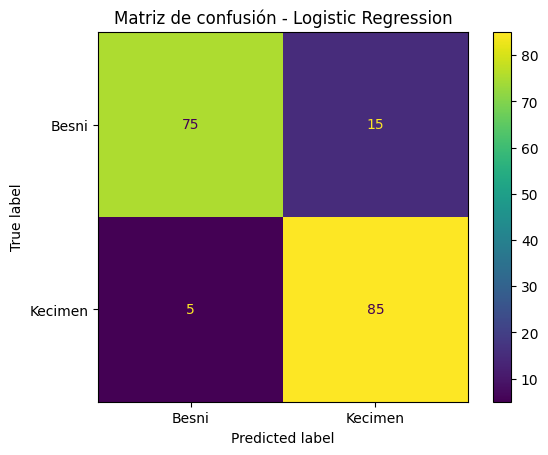

In [81]:
matriz = confusion_matrix(y_test, y_test_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=le.classes_
)

disp.plot()
plt.title("Matriz de confusión - Logistic Regression")
plt.show()

En la matriz de confusión se observa que el modelo clasificó correctamente **75 casos de Besni** y **85 casos de Kecimen**, logrando un total de **160 aciertos sobre 180 casos**. También se observan **20 errores**: 15 casos reales de Besni fueron clasificados como Kecimen, y 5 casos reales de Kecimen fueron clasificados como Besni. Esto muestra que el modelo tuvo un buen desempeño general, aunque confundió más casos de Besni como Kecimen.

**El modelo de Regresión Logística obtuvo un buen desempeño**, con una accuracy de aproximadamente **0.89** en el conjunto de prueba. Las métricas de precision, recall y F1-score también fueron altas y equilibradas entre ambas clases.


## 5- **Otro clasificador**

### 5.1 Elija otro modelo para entrenar un clasificador

Elija alguno de los modelos vistos: kNN, SVM o MLP para entrenar un clasificador usando los parámetros por defecto de sklearn.

Justifique su elección.

**Respuesta**: Se eligió el ***modelo SVM*** porque permite comparar la Regresión Logística con un clasificador más flexible. Mientras la Regresión Logística busca una separación lineal entre clases, SVM puede encontrar fronteras de decisión más complejas, especialmente usando su kernel RBF por defecto.

### 5.2 Entrenamiento del modelo.

In [82]:
modelo_svm = SVC()

modelo_svm.fit(X_train_scaled, y_train)

SVC()

**Ahora hacemos predicciones para entrenamiento y test:**

In [83]:
y_train_pred_svm = modelo_svm.predict(X_train_scaled)
y_test_pred_svm = modelo_svm.predict(X_test_scaled)

### 5.3 Evaluación del desempeño

# Metricas:

In [84]:
metricas_svm = {
    "Train": {
        "Accuracy": accuracy_score(y_train, y_train_pred_svm),
        "Precision": precision_score(y_train, y_train_pred_svm),
        "Recall": recall_score(y_train, y_train_pred_svm),
        "F1-score": f1_score(y_train, y_train_pred_svm)
    },
    "Test": {
        "Accuracy": accuracy_score(y_test, y_test_pred_svm),
        "Precision": precision_score(y_test, y_test_pred_svm),
        "Recall": recall_score(y_test, y_test_pred_svm),
        "F1-score": f1_score(y_test, y_test_pred_svm)
    }
}

metricas_svm_df = pd.DataFrame(metricas_svm).T
metricas_svm_df

,Accuracy,Precision,Recall,F1-score
Train,0.866667,0.838462,0.908333,0.872000
Test,0.877778,0.826923,0.955556,0.886598


In [85]:
print(classification_report(y_test, y_test_pred_svm, target_names=le.classes_))

              precision    recall  f1-score   support

       Besni       0.95      0.80      0.87        90
     Kecimen       0.83      0.96      0.89        90

    accuracy                           0.88       180
   macro avg       0.89      0.88      0.88       180
weighted avg       0.89      0.88      0.88       180



El modelo SVM obtuvo un buen desempeño, con una accuracy cercana a 0.88 en el conjunto de test. Las métricas de entrenamiento y prueba son similares, por lo que no se observa sobreajuste importante. Comparado con la Regresión Logística, **los resultados son muy parecidos**, aunque SVM muestra un recall más alto para la clase Kecimen y un recall más bajo para Besni. En general, ambos modelos logran clasificar correctamente la mayoría de los casos.


**Matriz de confusión**

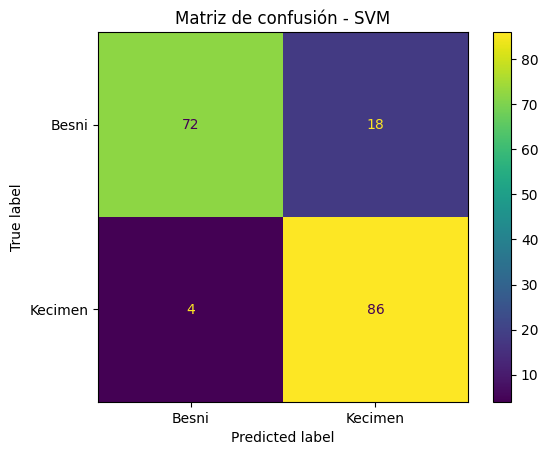

In [86]:
matriz_svm = confusion_matrix(y_test, y_test_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_svm,
    display_labels=le.classes_
)

disp.plot()
plt.title("Matriz de confusión - SVM")
plt.show()

En la matriz de confusión del modelo SVM se observa que clasificó correctamente **72 casos de Besni** y **86 casos de Kecimen**, con un total de **158 aciertos sobre 180 casos**. También se registraron **22 errores**: 18 casos reales de Besni fueron clasificados como Kecimen, y 4 casos reales de Kecimen fueron clasificados como Besni. El resultado es muy similar al obtenido con Regresión Logística, aunque SVM confundió levemente más casos de Besni.


# Conclusión sobre los modelos:

Comparando ambos modelos, **la Regresión Logística obtuvo un rendimiento levemente superior al SVM**. Si bien ambos clasificadores tuvieron métricas muy similares, la Regresión Logística alcanzó una accuracy y un F1-score apenas mayores, además de presentar menos errores en la matriz de confusión. Por este motivo, para esta primera comparación, se considera que la Regresión Logística tuvo el mejor desempeño general.

## 6  Tuneo de hiperparámetros

En esta sección debe modificar probar cómo la modificación de un hiperparámetro del modelo elegido en punto 5) afecta en los resultados.

Justifique y realice el experimento en esta sección.

**Respuesta:**

En este caso se decidió experimentar con el hiperparámetro **C** del modelo SVM, ya que controla el nivel de regularización del clasificador. Un valor bajo de **C** permite más errores y genera un modelo más simple, mientras que un valor alto intenta clasificar mejor los datos de entrenamiento, pero puede aumentar el riesgo de sobreajuste.

Por este motivo, se probaron distintos valores de **C** para observar cómo cambia el desempeño del modelo en entrenamiento y test, y evaluar si una mayor flexibilidad mejora o no los resultados.


In [87]:
valores_C = [0.1, 1, 10, 100]

resultados_svm = []

for c in valores_C:
    modelo = SVC(C=c, kernel="rbf")
    modelo.fit(X_train_scaled, y_train)

    y_train_pred = modelo.predict(X_train_scaled)
    y_test_pred = modelo.predict(X_test_scaled)

    resultados_svm.append({
        "C": c,
        "Accuracy Train": accuracy_score(y_train, y_train_pred),
        "Accuracy Test": accuracy_score(y_test, y_test_pred),
        "Precision Test": precision_score(y_test, y_test_pred),
        "Recall Test": recall_score(y_test, y_test_pred),
        "F1-score Test": f1_score(y_test, y_test_pred)
    })

resultados_svm_df = pd.DataFrame(resultados_svm)
resultados_svm_df

,C,Accuracy Train,Accuracy Test,Precision Test,Recall Test,F1-score Test
0,0.1,0.869444,0.872222,0.825243,0.944444,0.880829
1,1.0,0.866667,0.877778,0.826923,0.955556,0.886598
2,10.0,0.870833,0.877778,0.826923,0.955556,0.886598
3,100.0,0.880556,0.861111,0.815534,0.933333,0.870466


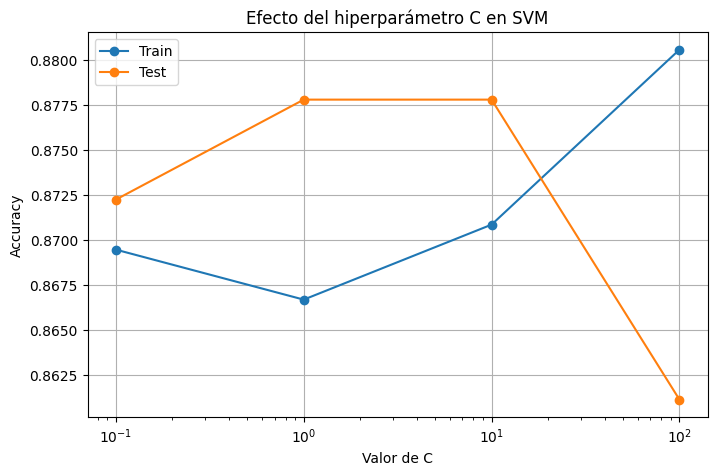

In [88]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_svm_df["C"], resultados_svm_df["Accuracy Train"], marker="o", label="Train")
plt.plot(resultados_svm_df["C"], resultados_svm_df["Accuracy Test"], marker="o", label="Test")
plt.xscale("log")
plt.xlabel("Valor de C")
plt.ylabel("Accuracy")
plt.title("Efecto del hiperparámetro C en SVM")
plt.legend()
plt.grid(True)
plt.show()

**Conclusión sobre el hiperparámetro C:**

Al modificar el hiperparámetro C se observó que los mejores resultados en test se obtuvieron con C = 1 y C = 10. Como ambos valores tuvieron el mismo rendimiento, se considera más conveniente mantener **C = 1**, ya que logra buen desempeño sin aumentar innecesariamente la complejidad del modelo. En cambio, con C = 100 el rendimiento en entrenamiento aumenta, pero el desempeño en test disminuye, lo que puede indicar una **leve tendencia al sobreajuste.**

# Ampliación del analisís de los hiperparámetros:

**Se amplió el experimento comparando distintos kernels junto con distintos valores de C, para buscar la mejor combinación de hiperparámetros.**

In [89]:
valores_C = [0.1, 1, 10, 100]
kernels = ["linear", "rbf", "poly", "sigmoid"]

resultados = []

for kernel in kernels:
    for c in valores_C:
        modelo = SVC(C=c, kernel=kernel)
        modelo.fit(X_train_scaled, y_train)

        y_train_pred = modelo.predict(X_train_scaled)
        y_test_pred = modelo.predict(X_test_scaled)

        resultados.append({
            "Kernel": kernel,
            "C": c,
            "Accuracy Train": accuracy_score(y_train, y_train_pred),
            "Accuracy Test": accuracy_score(y_test, y_test_pred),
            "Precision Test": precision_score(y_test, y_test_pred),
            "Recall Test": recall_score(y_test, y_test_pred),
            "F1-score Test": f1_score(y_test, y_test_pred)
        })

resultados_kernel_c = pd.DataFrame(resultados)
resultados_kernel_c

,Kernel,C,Accuracy Train,Accuracy Test,Precision Test,Recall Test,F1-score Test
0,linear,0.1,0.868056,0.872222,0.831683,0.933333,0.879581
1,linear,1.0,0.865278,0.900000,0.860000,0.955556,0.905263
2,linear,10.0,0.863889,0.894444,0.851485,0.955556,0.900524
3,linear,100.0,0.870833,0.888889,0.843137,0.955556,0.895833
4,rbf,0.1,0.869444,0.872222,0.825243,0.944444,0.880829
5,rbf,1.0,0.866667,0.877778,0.826923,0.955556,0.886598
6,rbf,10.0,0.870833,0.877778,0.826923,0.955556,0.886598
7,rbf,100.0,0.880556,0.861111,0.815534,0.933333,0.870466
8,poly,0.1,0.806944,0.800000,0.717742,0.988889,0.831776
9,poly,1.0,0.831944,0.838889,0.842697,0.833333,0.837989


**Graficamos la comparación para visualizar mejor:**

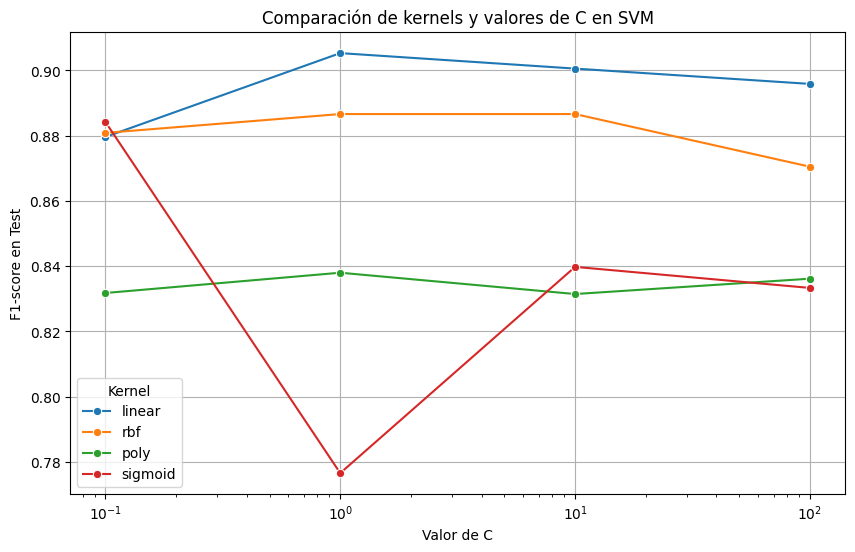

In [90]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=resultados_kernel_c,
    x="C",
    y="F1-score Test",
    hue="Kernel",
    marker="o"
)

plt.xscale("log")
plt.title("Comparación de kernels y valores de C en SVM")
plt.xlabel("Valor de C")
plt.ylabel("F1-score en Test")
plt.grid(True)
plt.show()

# Conclusión de los hiperparámetros:

Al comparar distintas combinaciones de hiperparámetros en el modelo SVM, se observó que la mejor combinación fue **kernel lineal con C = 1**. Esta configuración obtuvo las mejores métricas en el conjunto de test, con una **accuracy de 0.90** y un **F1-score de 0.905**.

Además, este resultado fue levemente superior al obtenido con Regresión Logística, que había alcanzado una accuracy aproximada de **0.89** y un F1-score de **0.895**. Por lo tanto, luego del tuneo de hiperparámetros, el modelo SVM con kernel lineal y C = 1 mostró el mejor desempeño general.


# Matriz de confusión con SVC lineal + c=1 (mejor combinación encontrada)

              precision    recall  f1-score   support

       Besni       0.95      0.84      0.89        90
     Kecimen       0.86      0.96      0.91        90

    accuracy                           0.90       180
   macro avg       0.91      0.90      0.90       180
weighted avg       0.91      0.90      0.90       180



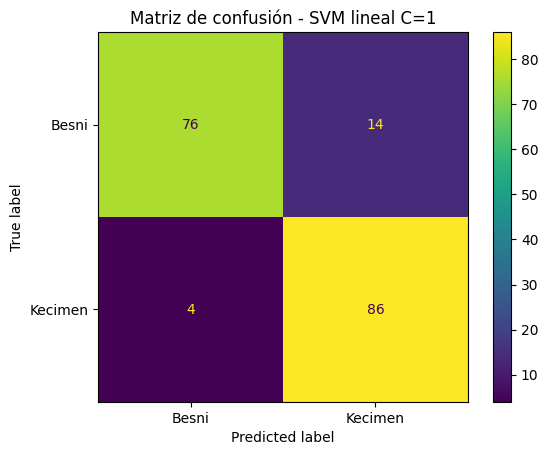

In [99]:
# Mejor combinación encontrada
svm_mejor = SVC(kernel="linear", C=1)

# Entrenamiento
svm_mejor.fit(X_train_scaled, y_train)

# Predicción en test
y_test_pred_svm_mejor = svm_mejor.predict(X_test_scaled)

# Reporte
print(classification_report(y_test, y_test_pred_svm_mejor, target_names=le.classes_))

# Matriz de confusión
matriz_svm_mejor = confusion_matrix(y_test, y_test_pred_svm_mejor)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_svm_mejor,
    display_labels=le.classes_
)

disp.plot()
plt.title("Matriz de confusión - SVM lineal C=1")
plt.show()

Con la mejor combinación de hiperparámetros, **SVM con kernel lineal y C = 1**, el modelo obtuvo una **accuracy de 0.90** en el conjunto de test. En la matriz de confusión se observa que clasificó correctamente **76 casos de Besni** y **86 casos de Kecimen**, con un total de **162 aciertos sobre 180 casos**. Los errores fueron bajos: 14 casos reales de Besni fueron clasificados como Kecimen y 4 casos reales de Kecimen fueron clasificados como Besni. Esto muestra que el tuneo de hiperparámetros mejoró levemente el rendimiento general del modelo.


# BONUS 1

Si su dataset estaba relativamente balanceado, como bonus pruebe entrenar otro modelo clasificador diferente y comparar resultados con su clasificador elegido en 5) y el modelo elegido 6) luego del tuneo de hiperparámetros.



**Respuesta:**

**Entrenar kNN**

In [92]:
modelo_knn = KNeighborsClassifier()

modelo_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

**Predicciones:**

In [93]:
y_train_pred_knn = modelo_knn.predict(X_train_scaled)
y_test_pred_knn = modelo_knn.predict(X_test_scaled)

# **Métricas kNN**

In [94]:
metricas_knn = {
    "Train": {
        "Accuracy": accuracy_score(y_train, y_train_pred_knn),
        "Precision": precision_score(y_train, y_train_pred_knn),
        "Recall": recall_score(y_train, y_train_pred_knn),
        "F1-score": f1_score(y_train, y_train_pred_knn)
    },
    "Test": {
        "Accuracy": accuracy_score(y_test, y_test_pred_knn),
        "Precision": precision_score(y_test, y_test_pred_knn),
        "Recall": recall_score(y_test, y_test_pred_knn),
        "F1-score": f1_score(y_test, y_test_pred_knn)
    }
}

metricas_knn_df = pd.DataFrame(metricas_knn).T
metricas_knn_df

,Accuracy,Precision,Recall,F1-score
Train,0.890278,0.872679,0.913889,0.892809
Test,0.861111,0.809524,0.944444,0.871795


In [95]:
print(classification_report(y_test, y_test_pred_knn, target_names=le.classes_))

              precision    recall  f1-score   support

       Besni       0.93      0.78      0.85        90
     Kecimen       0.81      0.94      0.87        90

    accuracy                           0.86       180
   macro avg       0.87      0.86      0.86       180
weighted avg       0.87      0.86      0.86       180



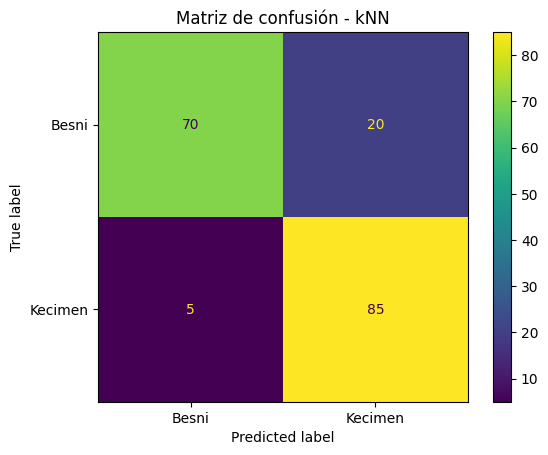

In [96]:
matriz_knn = confusion_matrix(y_test, y_test_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_knn,
    display_labels=le.classes_
)

disp.plot()
plt.title("Matriz de confusión - kNN")
plt.show()

**Conclusión modelo KNN:**

El modelo kNN obtuvo un rendimiento aceptable, con una accuracy de **0.86** en test. En la matriz de confusión se observa que clasificó correctamente **70 casos de Besni** y **85 casos de Kecimen**, con un total de **155 aciertos sobre 180 casos**. Sin embargo, cometió más errores que los modelos anteriores, especialmente al clasificar casos reales de Besni como Kecimen. Por lo tanto, kNN tuvo un desempeño menor que SVM y Regresión Logística en este dataset.


# **Comparacion de los modelos:**

In [97]:
comparacion_final = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "SVM original",
        "SVM tuneado",
        "kNN"
    ],
    "Accuracy Test": [
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_svm),
        accuracy_score(y_test, y_test_pred_svm_mejor),
        accuracy_score(y_test, y_test_pred_knn)
    ],
    "Precision Test": [
        precision_score(y_test, y_test_pred_lr),
        precision_score(y_test, y_test_pred_svm),
        precision_score(y_test, y_test_pred_svm_mejor),
        precision_score(y_test, y_test_pred_knn)
    ],
    "Recall Test": [
        recall_score(y_test, y_test_pred_lr),
        recall_score(y_test, y_test_pred_svm),
        recall_score(y_test, y_test_pred_svm_mejor),
        recall_score(y_test, y_test_pred_knn)
    ],
    "F1-score Test": [
        f1_score(y_test, y_test_pred_lr),
        f1_score(y_test, y_test_pred_svm),
        f1_score(y_test, y_test_pred_svm_mejor),
        f1_score(y_test, y_test_pred_knn)
    ]
})

comparacion_final

,Modelo,Accuracy Test,Precision Test,Recall Test,F1-score Test
0,Regresión Logística,0.888889,0.850000,0.944444,0.894737
1,SVM original,0.877778,0.826923,0.955556,0.886598
2,SVM tuneado,0.900000,0.860000,0.955556,0.905263
3,kNN,0.861111,0.809524,0.944444,0.871795


# Comparación final

En la comparación final se observa que el mejor modelo fue el **SVM tuneado**, con **kernel lineal y C = 1**, alcanzando una accuracy de **0.90** y un F1-score de **0.905** en test. La Regresión Logística también tuvo un buen desempeño, con métricas muy cercanas, pero quedó levemente por debajo. El SVM original mejoró luego del tuneo de hiperparámetros, mientras que kNN obtuvo resultados aceptables, aunque inferiores al resto. En conclusión, el ajuste de hiperparámetros permitió mejorar el rendimiento del SVM y convertirlo en el mejor modelo para este dataset.


# BONUS 2

Si su dataset estaba desbalanceado, puebe utilizar alguna técnica para lidiar con el desbalance de clases durante el entrenamiento.

1) Ofrezca una comparativa de entrenar y evaluar modelos de Logistic regression con y sin class_weight='balanced' o el modelo SVC con y sin class_weight='balanced'

2) Pruebe entrenar KNN con y sin uso de SMOTE

( Ver apunte sobre Desbalance de clases de la cátedra )



**El Bonus 2 no se aplicó porque el dataset se encuentra balanceado. La variable objetivo presenta 450 registros de la clase Kecimen y 450 registros de la clase Besni, por lo que no fue necesario utilizar técnicas para tratar desbalance de clases, como `class_weight="balanced"` o SMOTE.**


## 7- Conclusiones

Fundamente, justifique con sus palabras.

**Respuesta:**

En este trabajo se utilizó el dataset **Raisin**, cuyo objetivo era clasificar pasas de uva en dos clases: **Kecimen** y **Besni**. Primero se realizó un análisis exploratorio para conocer la estructura del dataset, revisar valores faltantes, duplicados, distribuciones, outliers y relaciones entre variables.

Luego se realizó el preprocesamiento, donde se codificó la variable objetivo, se dividieron los datos en entrenamiento y test, y se aplicó estandarización debido a las diferencias de escala entre las variables. En una primera etapa se entrenó una **Regresión Logística**, que obtuvo buenos resultados generales.

Después se entrenó un segundo clasificador, **SVM**, y se comparó su desempeño con el modelo anterior. Inicialmente los resultados fueron similares, pero luego del tuneo de hiperparámetros se encontró que la mejor combinación fue **SVM con kernel lineal y C = 1**. Esta configuración obtuvo una accuracy de **0.90** y un F1-score de **0.905** en test, superando levemente a la Regresión Logística.

Además, en el Bonus 1 se entrenó un modelo **kNN**, que obtuvo un rendimiento aceptable, aunque inferior al de Regresión Logística y SVM. Esto permitió comparar distintos enfoques de clasificación sobre el mismo dataset.

En conclusión, todos los modelos lograron resultados aceptables, pero el mejor desempeño final se obtuvo con **SVM lineal con C = 1**, mostrando que para este dataset una separación lineal fue suficiente para clasificar correctamente la mayoría de los casos.



# Referencias

Mencione los recursos utilizados

**Referencias**

* UCI Machine Learning Repository. *Raisin Dataset*. Utilizado como fuente del dataset para el problema de clasificación entre las clases Kecimen y Besni.

* Scikit-learn. *LogisticRegression*. Documentación utilizada para implementar el modelo de Regresión Logística.

* Scikit-learn. *SVC*. Documentación utilizada para implementar el modelo SVM y el tuneo de hiperparámetros `C` y `kernel`.

* Scikit-learn. *StandardScaler*. Documentación utilizada para la estandarización de las variables numéricas.

* Scikit-learn. *classification_report*. Documentación utilizada para obtener métricas de evaluación como precision, recall y F1-score.
